# VisXAI: Graph (PyTorch Geometric) Path Demo

This is the third and final paradigm demo, alongside `tree_demo.ipynb`
(fingerprints + SHAP) and `sequence_demo.ipynb` (tokens + attention). The
pipeline here is:

`generate_graph_representation` (SMILES → node/edge features) →
`PyTorchGNNWrapper` (wraps a trained GNN) →
`IntegratedGradientsExplainer` **and** `GradCAMExplainer` (two different
graph XAI algorithms) → `RDKitSVGVisualizer` (the same 2D renderer used by
every other path, unchanged).

Like `sequence_demo.ipynb`, the model here is **actually trained** via
real gradient descent — not left at random untrained weights the way the
unit tests use it (those only need to check the explainer math, not learn
anything real).


In [1]:
import torch
from IPython.display import SVG, display
from torch_geometric.data import Batch
from torch_geometric.nn import global_mean_pool

from visxai.explainers.gradient_based import GradCAMExplainer, IntegratedGradientsExplainer
from visxai.features.graphs import generate_graph_representation
from visxai.models.pytorch_wrapper import PyTorchGNNWrapper
from visxai.visualizers.rdkit_2d import RDKitSVGVisualizer


## The dataset

Same synthetic task as `sequence_demo.ipynb`: **does this molecule
contain an aromatic ring?** (`any(atom.GetIsAromatic() for atom in
mol.GetAtoms())`, computed directly by RDKit — no external data.) Reusing
the exact same 12-molecule set and label lets this demo be read as "same
task, third paradigm" rather than introducing a new dataset to reason
about.

The set is balanced (6 aromatic / 6 non-aromatic) and, critically,
includes `cyclohexane` — a molecule *with* a ring that is *not* aromatic.
Without it, a model could get the task right by learning "contains any
ring" instead of actually detecting aromaticity; `cyclohexane` is the one
molecule that tells the two apart during training.


In [2]:
def atom_featurizer(atom):
    return [atom.GetAtomicNum(), atom.GetDegree()]


def bond_featurizer(bond):
    return [bond.GetBondTypeAsDouble()]


TRAIN_SMILES = {
    "ethanol": "CCO",
    "benzene": "c1ccccc1",
    "acetic_acid": "CC(=O)O",
    "pyrrolidine": "C1CCNC1",
    "aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "pyridine": "c1ccncc1",
    "ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "hexane": "CCCCCC",
    "cyclohexane": "C1CCCCC1",
    "toluene": "Cc1ccccc1",
    "acetamide": "CC(=O)N",
    "naphthalene": "c1ccc2ccccc2c1",
}

mol_reps = {
    name: generate_graph_representation(smiles, atom_featurizer, bond_featurizer)
    for name, smiles in TRAIN_SMILES.items()
}
labels = {
    name: float(any(atom.GetIsAromatic() for atom in rep.mol.GetAtoms()))
    for name, rep in mol_reps.items()
}

n_aromatic = sum(labels.values())
print(f"{int(n_aromatic)}/{len(labels)} aromatic")
for name, label in labels.items():
    print(f"  {name:12s} aromatic={bool(label)}")


6/12 aromatic
  ethanol      aromatic=False
  benzene      aromatic=True
  acetic_acid  aromatic=False
  pyrrolidine  aromatic=False
  aspirin      aromatic=True
  pyridine     aromatic=True
  ibuprofen    aromatic=True
  hexane       aromatic=False
  cyclohexane  aromatic=False
  toluene      aromatic=True
  acetamide    aromatic=False
  naphthalene  aromatic=True


Note what's *not* a feature here: `atom_featurizer` only exposes atomic
number and degree, and `bond_featurizer` only exposes bond order. RDKit's
own `atom.GetIsAromatic()` is deliberately **excluded** — including it
would leak the label directly into the input (every aromatic atom would
trivially self-report), making the explanation meaningless. The model has
to infer aromaticity from atomic-number/degree/bond-order structure
alone, the same way `sequence_demo.ipynb`'s tokenizer never encodes
aromaticity as its own token.


## Model

A small 2-layer message-passing GNN — the same `msg_lin`/`node_lin`
message-passing pattern used by `_TinyEdgeGNN` in
`tests/test_gradient_based.py` (compute a per-directed-edge message from
`concat(x[src], edge_attr)`, aggregate into destination nodes, combine
with a node-only linear transform, ReLU), stacked twice so there's a
real "first layer" vs. "last layer" distinction — `GradCAMExplainer`'s
`target_layer`/`edge_target_layer` choice below points at the *last*
layer, matching the conventional "last conv layer" choice from the
original (image) Grad-CAM paper. It's redefined here rather than
imported since the test class is test-private, the same framing
`sequence_demo.ipynb` used for its attention model.


In [3]:
# A 2-layer hand-rolled message-passing GNN over (x, edge_index, edge_attr, batch).
class TinyMessagePassingGNN(torch.nn.Module):
    def __init__(self, in_dim=2, edge_dim=1, hidden_dim=16, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.msg_lin1 = torch.nn.Linear(in_dim + edge_dim, hidden_dim)
        self.node_lin1 = torch.nn.Linear(in_dim, hidden_dim)
        self.msg_lin2 = torch.nn.Linear(hidden_dim + edge_dim, hidden_dim)
        self.node_lin2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.out_lin = torch.nn.Linear(hidden_dim, 1)

    @staticmethod
    def _message_passing_layer(x, edge_index, edge_attr, msg_lin, node_lin):
        src, dst = edge_index[0], edge_index[1]
        messages = msg_lin(torch.cat([x[src], edge_attr], dim=-1)).relu()
        agg = torch.zeros(x.shape[0], messages.shape[-1], dtype=messages.dtype)
        agg = agg.index_add(0, dst, messages)
        return (node_lin(x) + agg).relu()

    def forward(self, x, edge_index, edge_attr, batch):
        h = self._message_passing_layer(x, edge_index, edge_attr, self.msg_lin1, self.node_lin1)
        h = self._message_passing_layer(h, edge_index, edge_attr, self.msg_lin2, self.node_lin2)
        pooled = global_mean_pool(h, batch)
        return self.out_lin(pooled)


model = TinyMessagePassingGNN()


In [4]:
names = list(TRAIN_SMILES.keys())
train_batch = Batch.from_data_list([mol_reps[name].pyg_data for name in names])
label_tensor = torch.tensor([[labels[name]] for name in names], dtype=torch.float)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = torch.nn.BCEWithLogitsLoss()

model.train()
for epoch in range(150):
    optimizer.zero_grad()
    out = model(train_batch.x, train_batch.edge_index, train_batch.edge_attr, train_batch.batch)
    loss = loss_fn(out, label_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 15 == 0:
        print(f"epoch {epoch:3d}  loss={loss.item():.4f}")
print(f"epoch {epoch:3d}  loss={loss.item():.4f}  (final)")


epoch   0  loss=1.4459
epoch  15  loss=0.6902
epoch  30  loss=0.6133
epoch  45  loss=0.5180
epoch  60  loss=0.3448
epoch  75  loss=0.1725
epoch  90  loss=0.0593
epoch 105  loss=0.0212
epoch 120  loss=0.0102
epoch 135  loss=0.0063
epoch 149  loss=0.0046  (final)


### Sanity check: did the model actually learn anything?

If training worked, predictions should spread out toward 0 or 1 and track
the true labels — and, specifically, `cyclohexane` should come out
*non*-aromatic despite having a ring, confirming the model isn't just
counting rings.


In [5]:
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(
        model(train_batch.x, train_batch.edge_index, train_batch.edge_attr, train_batch.batch)
    )

for name, prob in zip(names, probs.numpy().ravel()):
    print(f"  {name:12s} P(aromatic)={prob:.3f}  true={labels[name]}")


  ethanol      P(aromatic)=0.000  true=0.0
  benzene      P(aromatic)=0.995  true=1.0
  acetic_acid  P(aromatic)=0.001  true=0.0
  pyrrolidine  P(aromatic)=0.007  true=0.0
  aspirin      P(aromatic)=0.997  true=1.0
  pyridine     P(aromatic)=0.988  true=1.0
  ibuprofen    P(aromatic)=0.997  true=1.0
  hexane       P(aromatic)=0.000  true=0.0
  cyclohexane  P(aromatic)=0.018  true=0.0
  toluene      P(aromatic)=0.998  true=1.0
  acetamide    P(aromatic)=0.002  true=0.0
  naphthalene  P(aromatic)=1.000  true=1.0


## Explaining aspirin with Integrated Gradients

`IntegratedGradientsExplainer` gives **signed** atom scores, and — since
this model consumes `edge_attr` (`PyTorchGNNWrapper(model,
uses_edge_attr=True)`) — **signed bond scores for every bond**, not just
the ones with an explicit SMILES character (contrast with the sequence
path's inherently partial bond coverage).


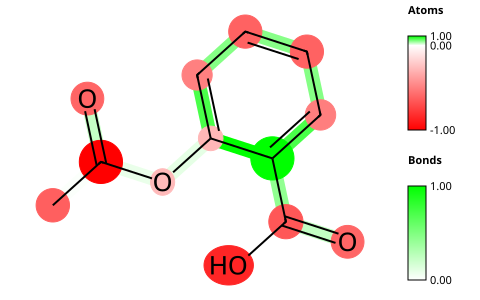

atoms scored: 13 / 13
bonds scored: 13 / 13
metadata: {'n_steps': 50, 'predicted_value': 5.741733551025391}


In [6]:
wrapper = PyTorchGNNWrapper(model, uses_edge_attr=True)
aspirin = mol_reps["aspirin"]

ig_explainer = IntegratedGradientsExplainer()
ig_explanation = ig_explainer.explain(wrapper, aspirin)

visualizer = RDKitSVGVisualizer()
display(SVG(visualizer.visualize(aspirin, ig_explanation)))

print(f"atoms scored: {len(ig_explanation.atom_scores)} / {aspirin.mol.GetNumAtoms()}")
print(f"bonds scored: {len(ig_explanation.bond_scores)} / {aspirin.mol.GetNumBonds()}")
print(f"metadata: {ig_explanation.metadata}")


Red = pushes the prediction down, green = pushes it up, white = neutral —
every atom and every bond gets a real (non-default) value, since node
`i` = atom `i` and every bond has an `edge_attr` vector to differentiate,
regardless of whether it has an explicit character in the SMILES string.


### Why does almost everything look colored, not just the ring?

If this is your first time reading one of these figures: it's normal for
the coloring to look spread across the whole molecule rather than sharply
picked out on just the aromatic ring &mdash; that's not a bug. For
aspirin, IG assigns a **negative score to nearly every atom** and a
**positive score to every bond**. The six aromatic ring bonds *are* the
top-scoring bonds (their distinctive bond order, 1.5, is the strongest
aromaticity signal available to this model), but only by a modest margin
over the rest.

**`RDKitSVGVisualizer` normalizes atom and bond scores on independent
scales by default** (`color_scale="separate"`, with its own "Atoms"/"Bonds"
legend for each) specifically because of a case like this one: aspirin's
IG bond scores (`+0.90` to `+2.08`) are more than ten times larger than its one positive atom score (`+0.16`). Under
`color_scale="combined"` (one shared min/max across every atom *and*
bond), that one positive atom would render at only **`t≈0.07`** &mdash;
barely tinted green, indistinguishable from "no signal" &mdash; purely
because a much larger bond magnitude happens to exist elsewhere in the
same molecule, even though `+0.16` is a real, meaningfully-sized value
*within the atom population itself*. Under the default `"separate"`
scaling that same atom renders at full saturation (`t=1.00`) instead,
since it's judged against the atom population's own range, not the
bond-inflated combined one.

**The color mapping is also sign-aware**, independently of `color_scale`
(see `_score_to_t`'s docstring for the full derivation). Two things this
fixes on this exact figure:

- A score population that has both positive and negative values (the
  atoms here, `-1.38..+0.16`) stays a zero-anchored diverging scale, but
  each side is now scaled to its *own* actual extreme rather than a
  shared symmetric span &mdash; so the one positive atom (`+0.16`, the
  *maximum* positive value that exists) reaches full green, not a muted
  `t≈0.11` capped by the negative side's larger `1.38` swing.
- A score population that's entirely one sign (the bonds here, all
  positive, `+0.90..+2.08`, nowhere near zero) switches to a sequential
  min→max stretch instead of forcing a zero anchor with no data near it.
  The least-positive bond used to render at `t≈0.43` (already fairly
  saturated green) purely because of the unused zero anchor below it,
  making every bond look similarly green; it now renders white
  (`t=0.00`), and the whole bond legend uses its full range.

**Highlighted atom-circle radius also now scales with score magnitude**
(`scale_atom_radius=True`, the default) &mdash; a second visual channel
alongside color, so a magnitude difference stays visible even where two
atoms' colors both land in a similarly-saturated range. Pass
`scale_atom_radius=False` for a uniform circle size on every highlighted
atom.

And what the model attributes is still spread across the whole molecule,
for two real, verified-not-buggy reasons (confirmed by checking every
atom/bond's score against RDKit's own `GetIsAromatic()`, and by checking
IG's completeness axiom holds *exactly* &mdash; `sum(atom_scores) +
sum(bond_scores) == predicted_value - baseline_prediction`, not just
asserted):

- **Global mean pooling.** Every atom feeds the pooled prediction equally
  regardless of position, so this tiny model has little structural
  incentive to *localize* its signal onto just the ring, the way an
  attention mechanism (`sequence_demo.ipynb`) naturally does.
- **Integrated Gradients on concatenated atom+edge inputs.** This
  architecture concatenates atom features with edge features before every
  nonlinear layer, so along IG's straight-line integration path, most of
  the credit for "aromatic" lands on the *bond* component (which directly
  carries the distinguishing bond-order value) and a small negative credit
  lands on the atom component almost everywhere &mdash; a known IG
  characteristic for models with strongly-interacting inputs, not a defect
  in the explainer.

Grad-CAM (below) shows a related but distinct pattern: about two thirds of
aspirin's atoms come out exactly `0.0` rather than uniformly negative, but
its nonzero bond scores are still spread across the whole molecule rather
than sharply confined to the ring, for the same underlying (mean-pooling)
reason.


### Raw vs. normalized legend numbers

The legend above prints **normalized** tick labels by default
(`legend_units="normalized"`) — each number is the exact same value `t`
that already determines that tick's color, so the number and the color
can never visually disagree. For the IG atom legend above (a range that
straddles zero), both the bottom and top ticks now reach the full
`-1.00`/`+1.00` extreme, since each side of zero is scaled independently
against its own actual data (see the cell above). For the IG bond legend
(all-positive, `+0.90..+2.08`), the bottom tick reads `0.00` (white) and
the top reads `1.00` — a plain min→max stretch, since forcing a zero
anchor would waste most of the bar on a region with no data.

Pass `legend_units="raw"` to get the raw-score tick labels instead
(`-1.38`, `0.00`, `0.16` for atoms; `0.90`, `2.08` for bonds) — same
colors either way, only the printed numbers change. Grad-CAM's legend
below is normalized the same way; since its scores are already
non-negative, its ticks land in `0..1` instead of `-1..1`.


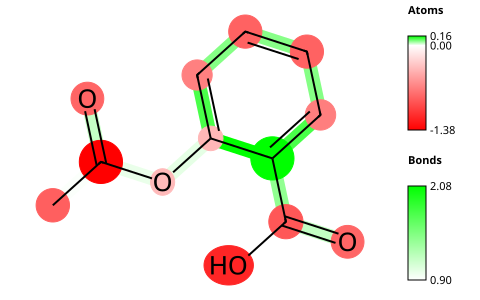

legend_units='raw' shown above; legend_units='normalized' (default) shown in the figure two cells up.


In [7]:
display(SVG(RDKitSVGVisualizer(legend_units="raw").visualize(aspirin, ig_explanation)))
print("legend_units='raw' shown above; legend_units='normalized' (default) shown in the figure two cells up.")

## Explaining aspirin with Grad-CAM

`GradCAMExplainer` takes a different approach: instead of interpolating
along a path from a baseline (Integrated Gradients), it does a single
forward+backward pass and reads off one specific layer's activations,
weighted by how much that layer's output affects the prediction. Passing
both `target_layer` (node-indexed) and `edge_target_layer` (edge-indexed)
gets **both** atom and bond scores from the same pair of hooks — the
canonical Grad-CAM formula doesn't care whether the activation it's
applied to is indexed by node or by directed edge.


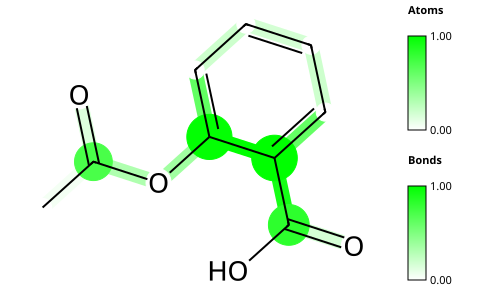

atoms scored: 13 / 13  (4 nonzero)
bonds scored: 13 / 13
metadata: {'predicted_value': 5.741733551025391}


In [8]:
cam_explainer = GradCAMExplainer(
    target_layer=model.node_lin2,
    edge_target_layer=model.msg_lin2,
)
cam_explanation = cam_explainer.explain(wrapper, aspirin)

display(SVG(visualizer.visualize(aspirin, cam_explanation)))

n_nonzero_atoms = sum(1 for v in cam_explanation.atom_scores.values() if v > 0)
print(f"atoms scored: {len(cam_explanation.atom_scores)} / {aspirin.mol.GetNumAtoms()}"
      f"  ({n_nonzero_atoms} nonzero)")
print(f"bonds scored: {len(cam_explanation.bond_scores)} / {aspirin.mol.GetNumBonds()}")
print(f"metadata: {cam_explanation.metadata}")


Grad-CAM's scores are **non-negative** (the final `ReLU` is part of the
algorithm's own definition, not a visualization choice), so the SVG above
renders white-to-green rather than red-to-green. It's normal — and not a
bug — for some atoms to come out exactly `0.0`: a small hidden dimension
gives the per-channel weights/activations less "room" to avoid cancelling
out for a given node. If every atom came out `0.0`, that would still be a
legitimate (if uninformative) result; here enough atoms are nonzero to
see real structure in the map.


## Integrated Gradients vs. Grad-CAM

Both explainers now cover atoms *and* bonds, but they trade off
differently:

- **`IntegratedGradientsExplainer`** — signed scores (shows what pushes
  the prediction down as well as up), requires an interpolation loop
  (`n_steps` forward/backward passes), and works for any model consuming
  continuous features, node or edge.
- **`GradCAMExplainer`** — non-negative scores only, needs just a single
  forward+backward pass, and directly reflects one specific layer's
  learned representation — which also means bond-level attribution is
  opt-in and only possible for architectures (like this one) that expose
  an edge-indexed intermediate activation, unlike IG's edge attribution
  which works for any `edge_attr`-consuming model.

Neither is strictly "better" — which one (or both) to use depends on
whether signed contributions or a specific layer's learned features are
what you're trying to inspect.


## Next steps

All three planned paradigms (tree/tabular, sequence, graph) now have a
working end-to-end demo. What's still missing, per `CAPABILITIES.md`:

- `visxai/models/hf_wrapper.py` — a convenience loader for real
  pretrained HuggingFace checkpoints (the sequence path works today
  against any hand-rolled model matching the calling convention; this
  would just make loading a real checkpoint more ergonomic).
- `visxai/visualizers/py3dmol_3d.py` — 3D visualization; everything here
  is 2D (`rdkit.Chem.Draw.rdMolDraw2D`).
- `README.md` / `docs/` — this repo doesn't have top-level docs yet
  beyond `CLAUDE.md`/`CAPABILITIES.md`.
